# M4: outlier rejection via a fitted rotated ellipse

`PLANbeh.md` M4: fit a rotated ellipse (PCA -- `features._points_pca`, the same machinery M2's shape features already use) to a distribution of clicks, flag points beyond `n_std` standard deviations along each principal axis as outliers.

Two levels, sharing the same plotting (`plotting.plot_subjects_outliers_grid`): **subject-level** -- each participant's own ellipse, fit to their own points; **group-level** -- one ellipse fit to a whole group/subgroup's pooled points, then applied back to each individual subject (does this subject's own data look like an outlier *relative to the group as a whole*, not relative to their own cloud). Exploratory throughout -- nothing here filters any persisted data, this is purely "what would get flagged."

In [1]:
import sys
sys.path.append('../scripts')

import features
import loader
import plotting

df = loader.load_behavioral()
N_STD = 2.0
categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## Subject-level: each participant's own ellipse

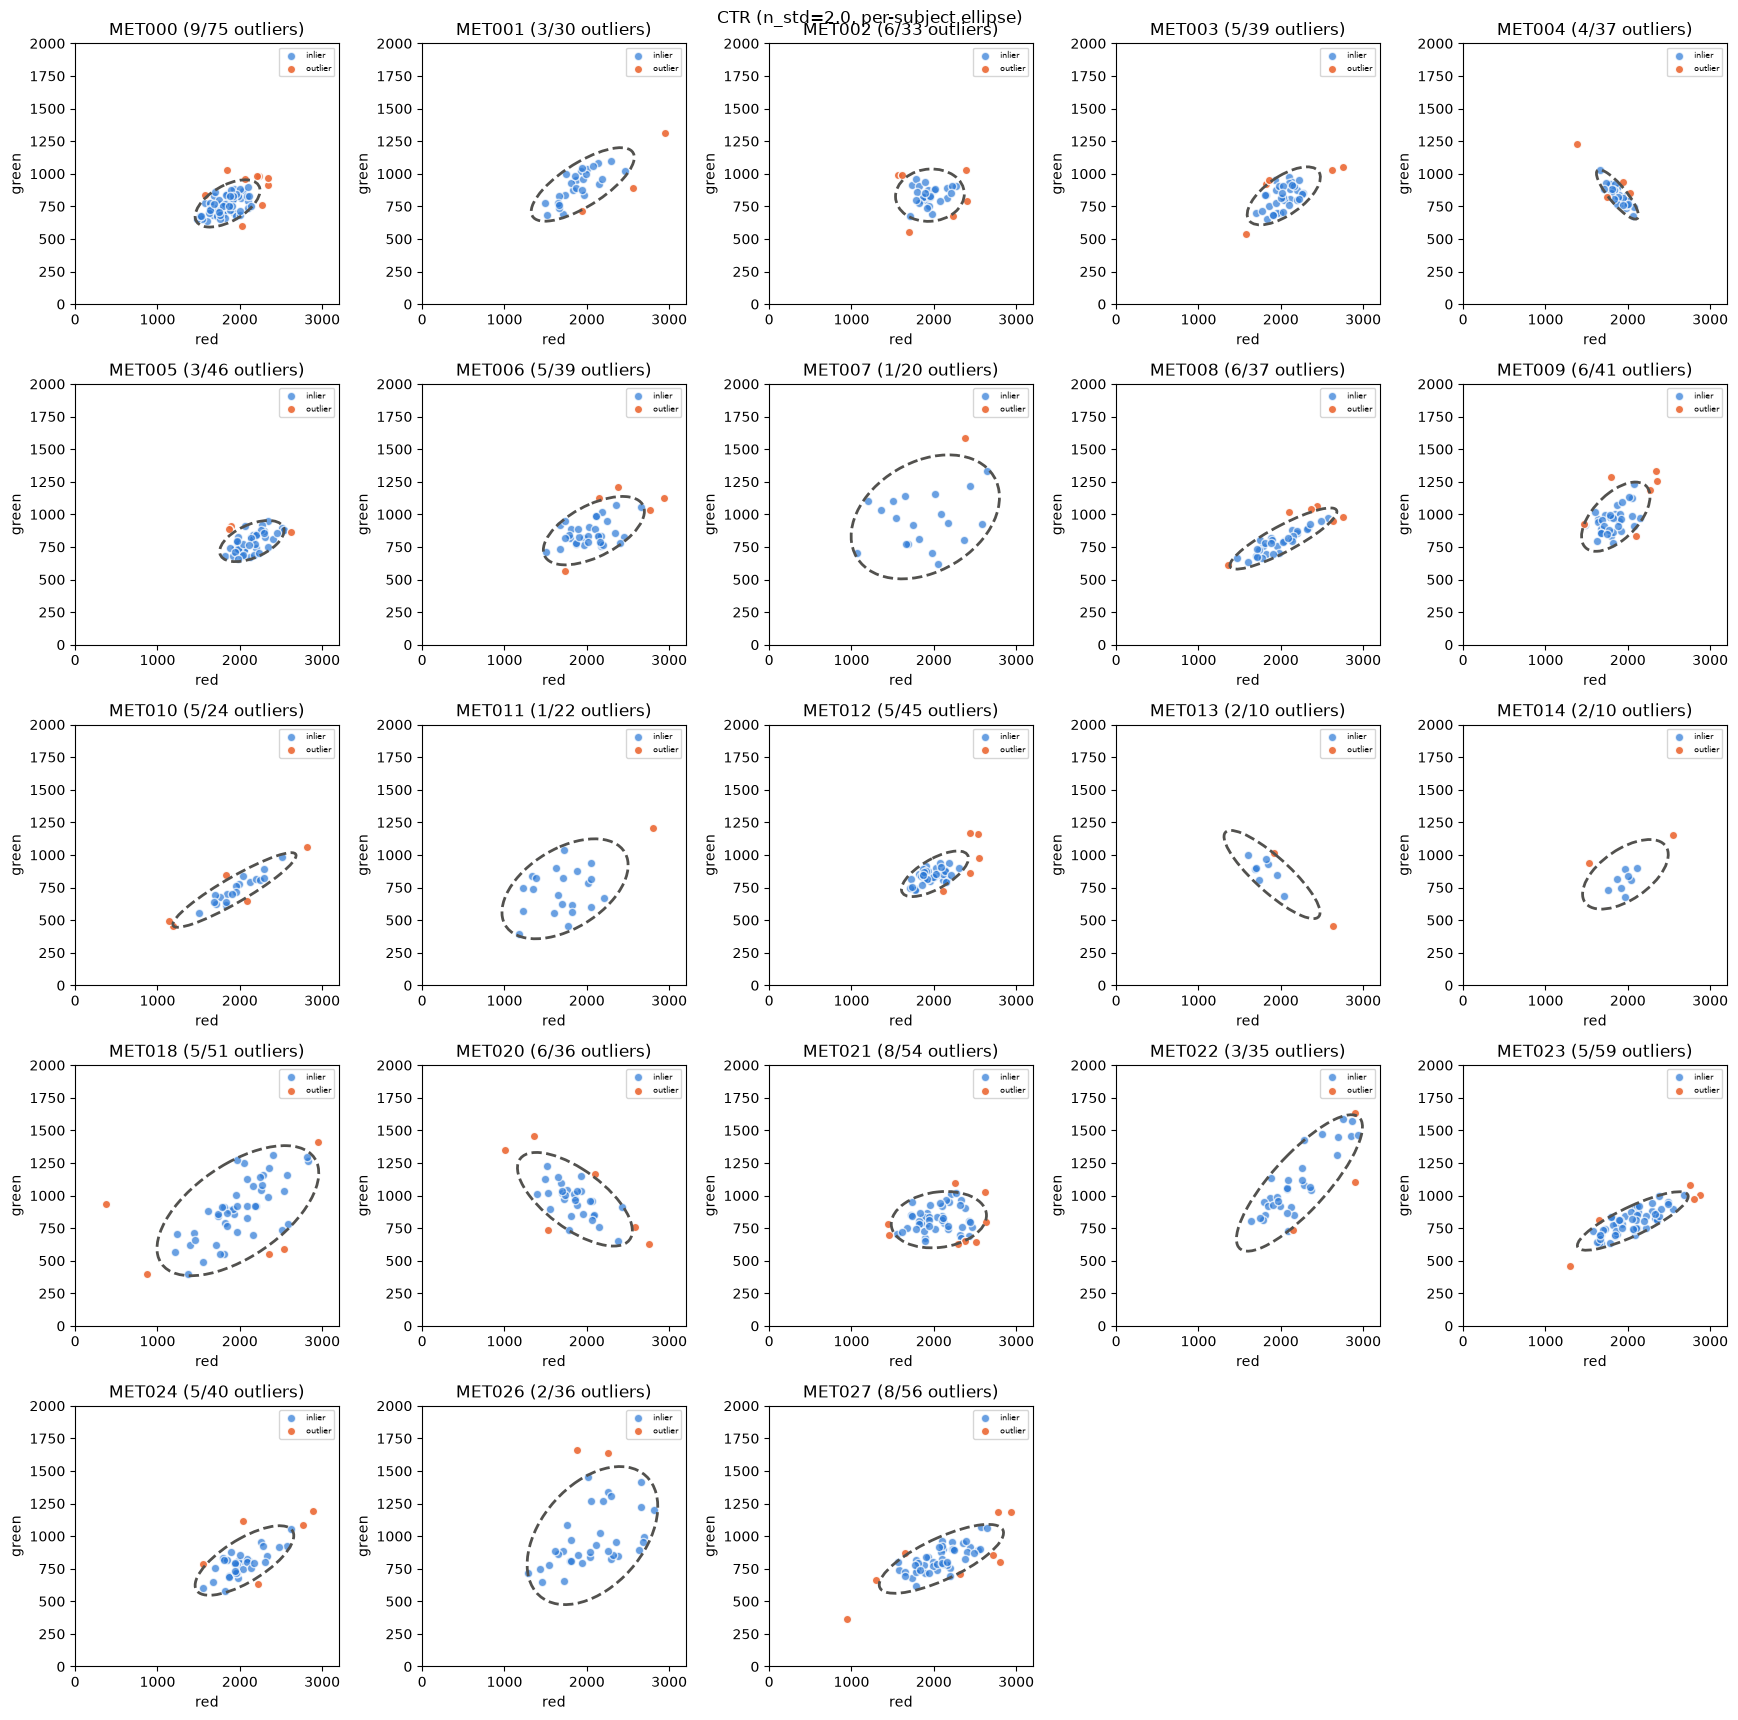

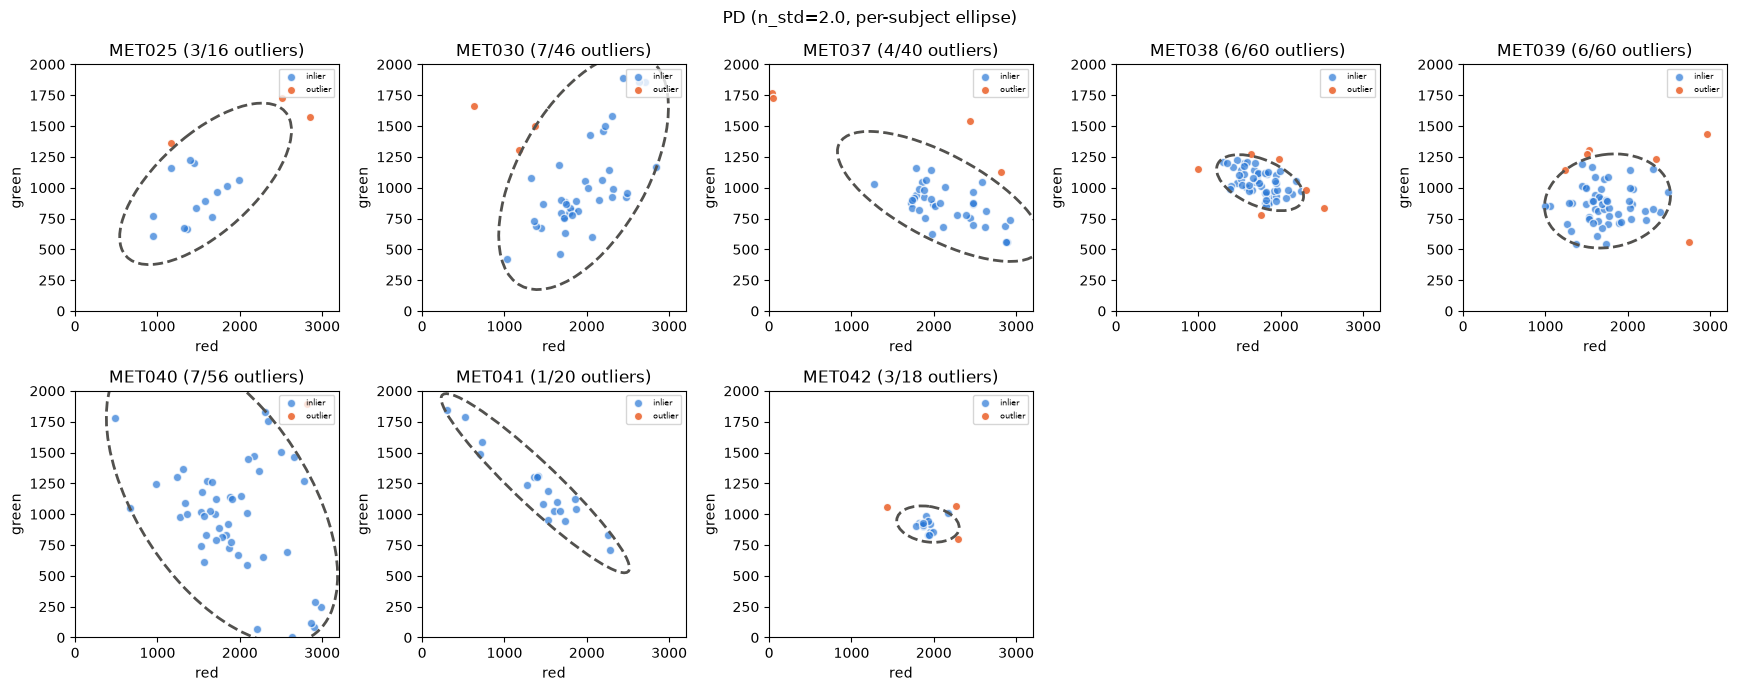

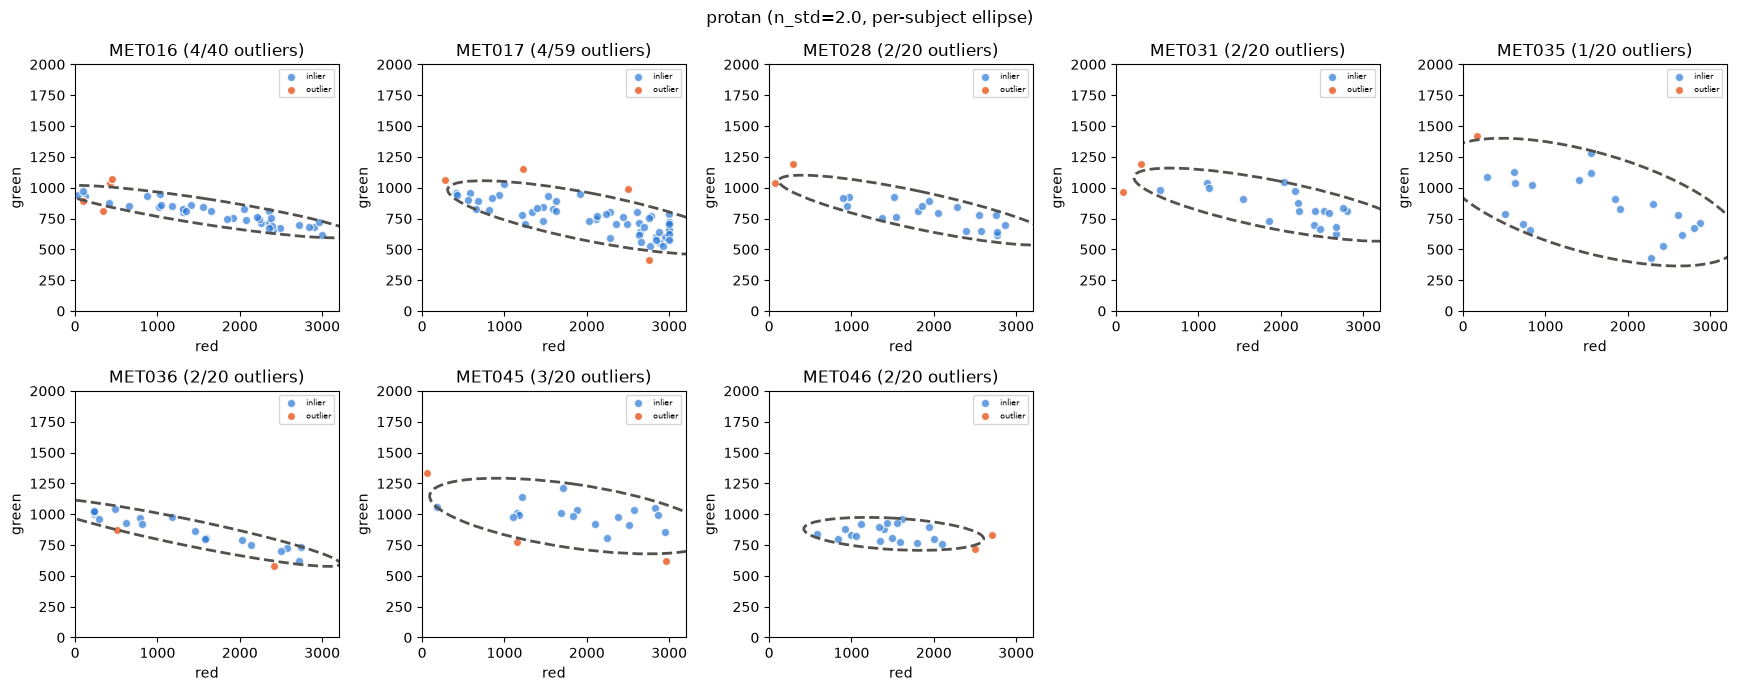

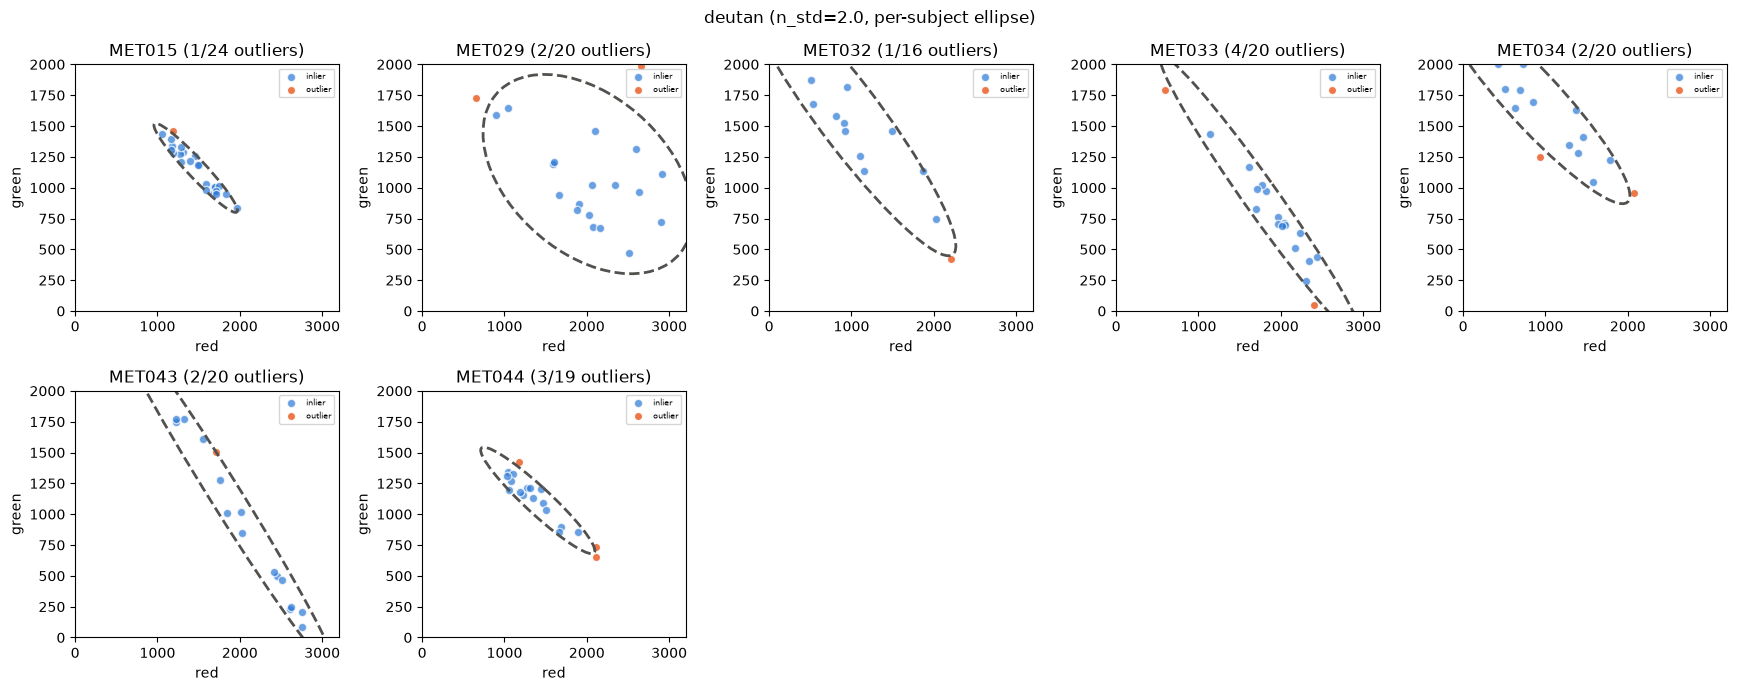

In [2]:
for cat in categories:
    plotting.plot_subjects_outliers_grid(df, group=cat.get('group'), subgroup=cat.get('subgroup'), n_std=N_STD)

## Group-level: one shared ellipse per group/subgroup, applied to every individual

First, how many of each group's points fall outside their own group's shared ellipse, broken down per subject -- the actual answer to "what would get flagged."

In [3]:
summaries = []
group_pcas = {}
for cat in categories:
    result = features.group_outliers(df, group=cat.get('group'), subgroup=cat.get('subgroup'), n_std=N_STD)
    group_pcas[cat['label']] = result['pca']
    per_subject = result['table'].groupby('sub_id')['is_outlier'].agg(['sum', 'count'])
    summaries.append({
        'label': cat['label'],
        'n_subjects': per_subject.shape[0],
        'n_clicks': len(result['table']),
        'n_flagged': int(result['table']['is_outlier'].sum()),
        'subjects_with_any_flagged': int((per_subject['sum'] > 0).sum()),
    })
import pandas as pd
pd.DataFrame(summaries)

,label,n_subjects,n_clicks,n_flagged,subjects_with_any_flagged
0,HC,23,875,110,21
1,PD,8,316,49,6
2,protan,8,219,23,6
3,deutan,7,139,16,5


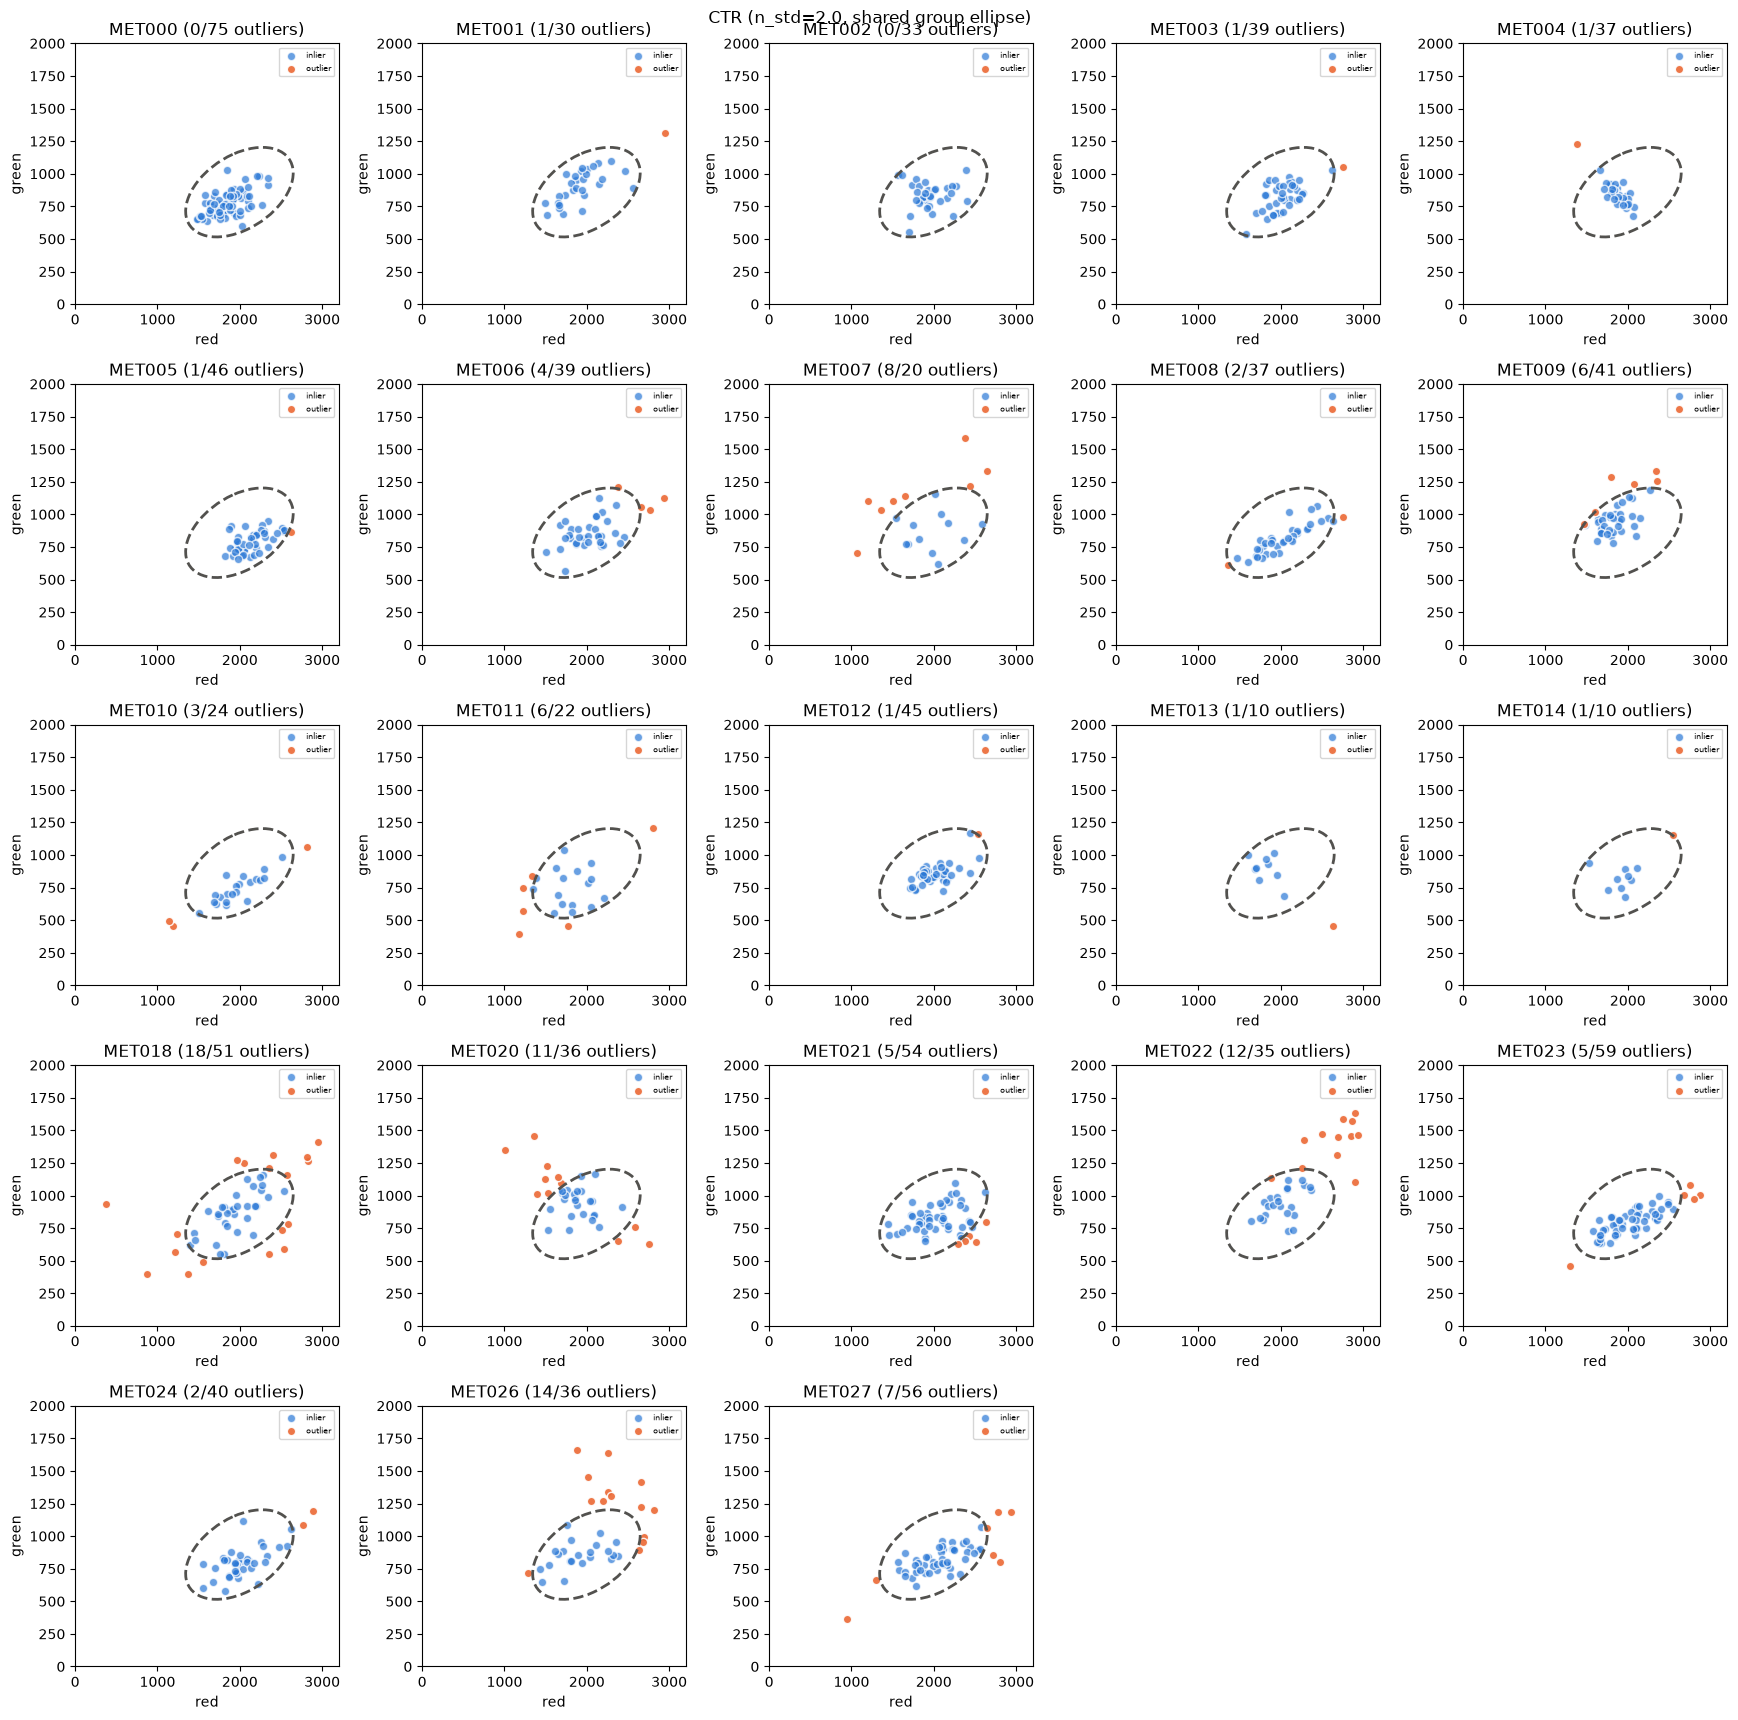

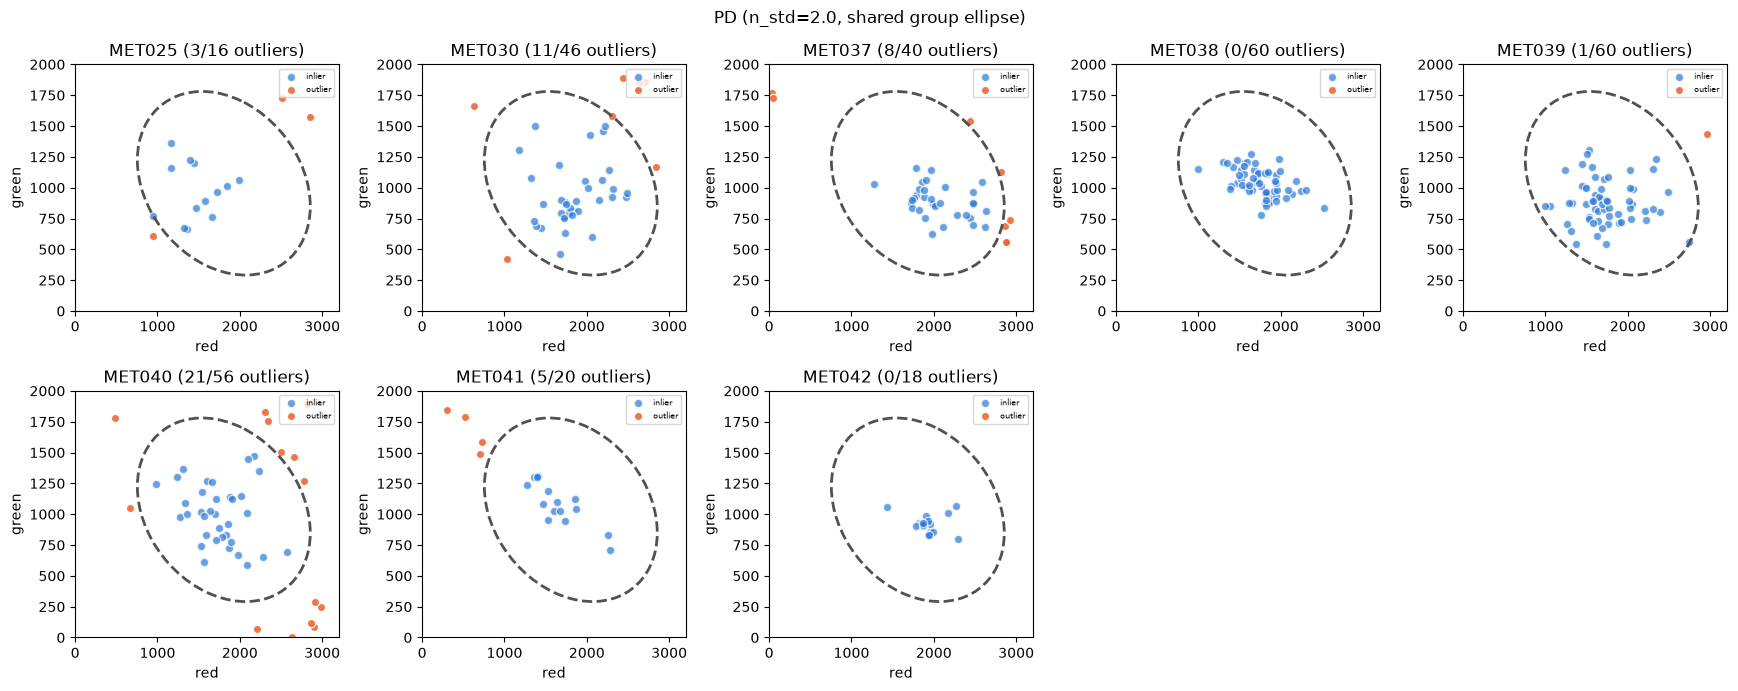

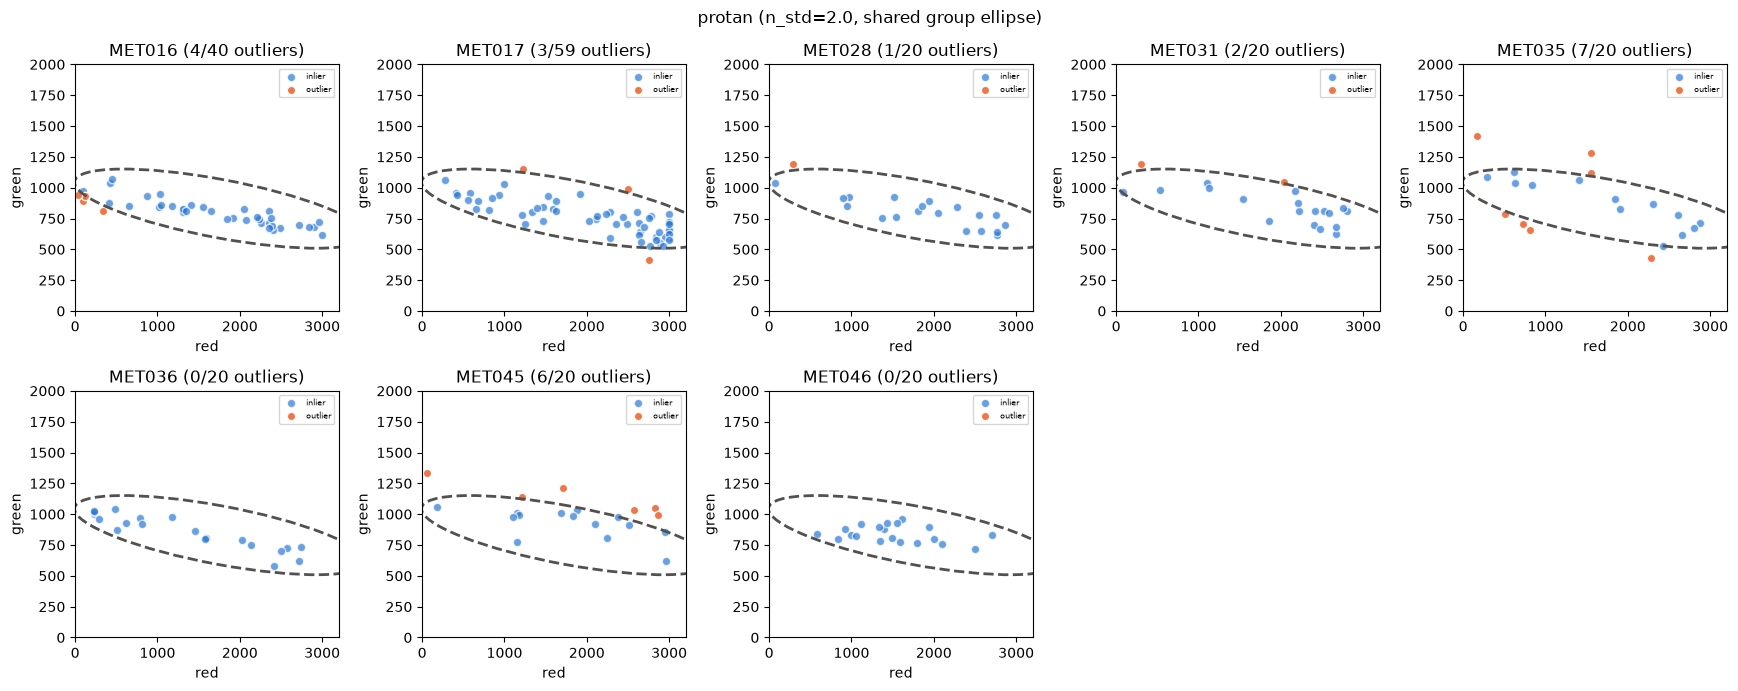

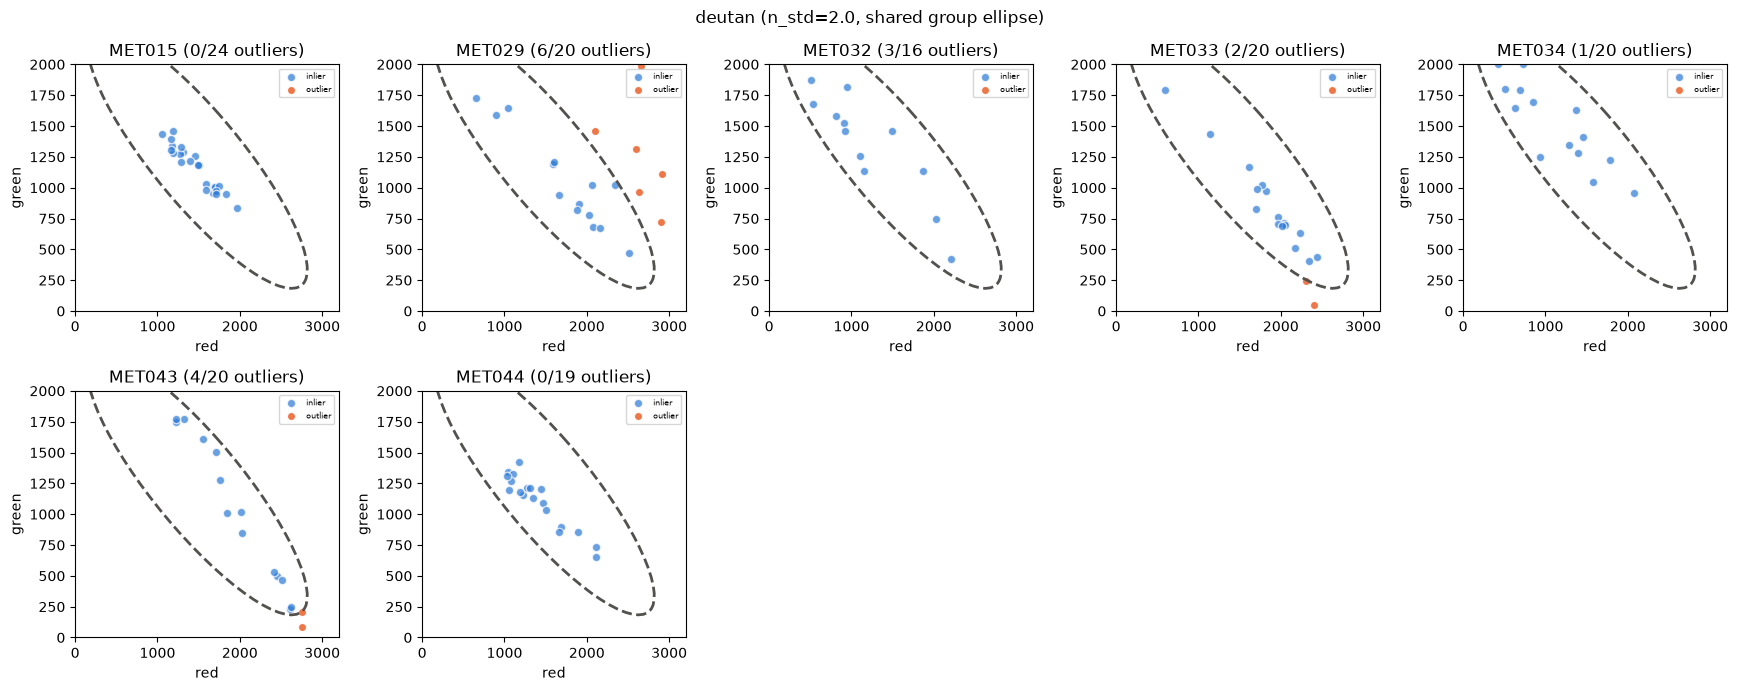

In [4]:
for cat in categories:
    plotting.plot_subjects_outliers_grid(df, group=cat.get('group'), subgroup=cat.get('subgroup'), n_std=N_STD, shared_pca=group_pcas[cat['label']])

## Summary

At `n_std=2.0`, the group-level shared ellipse flags a broadly similar fraction of clicks in every category -- HC 12.6% (110/875), PD 15.5% (49/316), protan 10.5% (23/219), deutan 11.5% (16/139) -- and nearly every subject in every group has at least one of their own points flagged (21/23 HC, 6/8 PD, 6/8 protan, 5/7 deutan). That's expected, not a red flag: with ~20-60 clicks per subject and a 2 SD boundary, most subjects will have at least one point drift out that far by chance alone under a roughly bivariate-normal cloud.

**Is this worth building into the pipeline?** Nothing here suggests a systematic per-group outlier problem -- the flagged fraction doesn't single out any one group as unusually messy, and the subject-level panels (first section) show the ellipses tracking each subject's own genuine click-cloud shape sensibly, not fighting real structure. Read as an honest "nothing alarming turned up" rather than a case for automatic rejection -- worth revisiting if a specific analysis later turns out to be sensitive to a handful of extreme clicks, but not a standing recommendation to filter data by default at this point. `n_std` is a parameter throughout, easy to tighten/loosen if that changes.